<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_3/blob/main/16_1_2_PRACTICE_Training_a_AllConvolutional_CNN_on_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN on CIFAR 10

We've used a fully connected NN with many layers to classify the 10 CIFAR10 classes. However, its performance was not very good (please go back and check its accuracy, as well as how many parameters the network had).

By adding convolutional layers to the beginning of a neural network, we can create a CNN that will be able to achieve betters results with less parameters.

IMPORTANT: We highly recommend using a GPU for this exercise. The training of the models takes a significant amount of time. You should write down the parameters and results of every run you make to compare and determine the best model.




## 1. AllConvolutional Network

In this case, we'll use the `All-CNN-C` variant of [the AllConvolutional network](https://arxiv.org/abs/1412.6806). This network was one of the first deep networks that proposed using only convolution operations to classify images. The network does not use MaxPooling layers; instead it relies on Convolutions with `strides=(2,2)` to downsample the feature maps. As with VGG, AllConvolutional relies on `3x3` convolutions and employs the strategy of duplicating the number of filters every time a subsampling operation reduces by 1/4 the number of pixels of the feature maps.

Note that the AllConvolutional model does not include a Flatten layer after the final convolutional layer, but instead relies on a combination of two special layers to generate the scores for each class.

First, a `Conv2D` layer with `10` feature maps as outputs and `1x1` convolutions converts the `192` feature maps into `10xHxW` scores. Then a [GlobalAveragePooling2D](https://keras.io/api/layers/pooling_layers/global_average_pooling2d) layer averages out the `HxW` spatial dimensions, leaving just `10` scores, one per class. Finally, the original article used a softmax directly over these `10` class scores. Instead, we propose you add a `Dense` layer with `softmax` activation to perform the final classification. This combination of Global Average Pooling with Dense layers has become a standard practice since it adds a bit of prediction power to the model.

**Hint:** your network should only have around 1M parameters.
**Hint:** Use `padding=same` to maintain make all intermediate spatial dimensions powers of 2 (32,16,8, etc)

In [2]:
from tensorflow import keras
from keras import layers

model = keras.Sequential([
    layers.InputLayer(input_shape=(32, 32, 3)),

    # Block 1: 64 filters, 32x32 spatial
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),  # Downsample to 16x16

    # Block 2: 128 filters, 16x16 spatial
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),  # Downsample to 8x8

    # Block 3: 256 filters, 8x8 spatial
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),  # Downsample to 4x4

    # Classification: 10 filters (1x1 conv)
    layers.Conv2D(10, kernel_size=(1, 1), activation='relu', padding='same'),

    # Global Average Pooling
    layers.GlobalAveragePooling2D(),

    # Final Dense layer
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 10)       │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 10)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,922,680 (7.33 MB)

 Trainable params: 1,922,680 (7.33 MB)

 Non-trainable params: 0 (0.00 B)

## 2. Data loading

You can load the data for the MNIST dataset with a single keras function: `tf.keras.datasets.cifar10.load_data`.


In [3]:
# Normalize data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# YOUR IMPLEMENTATION HERE (START)

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels from (N, 1) to (N,) shape
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# YOUR IMPLEMENTATION HERE (END)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"x_train min: {x_train.min()}, max: {x_train.max()}")
print(f"Unique classes: {len(set(y_train))}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
x_train shape: (50000, 32, 32, 3)
x_test shape: (10000, 32, 32, 3)
y_train shape: (50000,)
y_test shape: (10000,)
x_train min: 0.0, max: 1.0
Unique classes: 10


# 3. Training the model

CNNs are trained just the same as any NN model; you'll need to `compile` the model with an optimizer, a loss function, and some metrics to monitor the performance of the model.

Since this is a classification problem, you'll use a `categorical_crossentropy` loss, but check the encoding of the outputs to decide if it is `sparse` (labels) or dense (one-hot encoding).


Afterwards, you can just call the `fit` function as usual. Training for 30 epochs with a batch size of 128 should suffice to obtain a reasonably good accuracy on the test set (~79%). Save the result of the `fit` function to a variable named `history`.

In [4]:
# Compile the model
# YOUR IMPLEMENTATION HERE (START)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# YOUR IMPLEMENTATION HERE (END)

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=30, batch_size=128)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - accuracy: 0.0982 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.0977 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.0995 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.0970 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.0981 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.0994 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.0960 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.0980 - loss: 2.3027 - 

#4. Analyzing the accuracy curves

Let's visualize the accuracy for the train (`accuracy`) and test (`val_accuracy`) during training.

* Is the training accuracy always increasing? And the training loss?
* What about the test accuracy/loss?
* Is the model underfitting o overfitting?

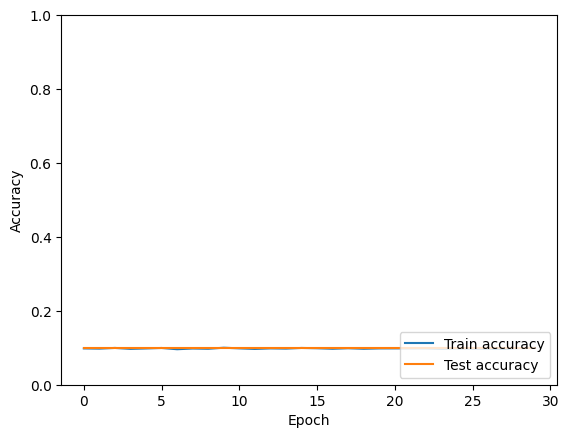

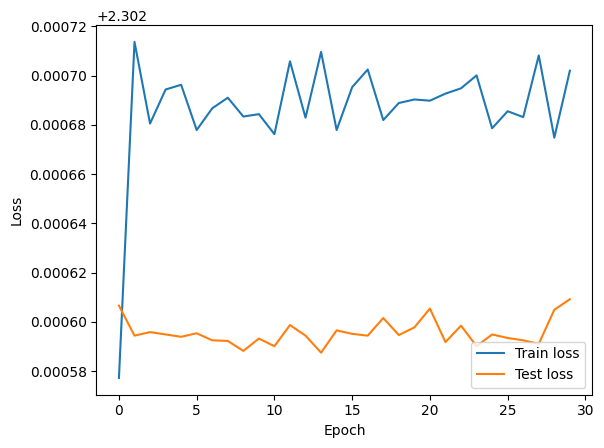

In [5]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train accuracy')
    plt.plot(history.history['val_accuracy'], label='Test accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.figure()

    plt.plot(history.history['loss'], label='Train loss')
    plt.plot(history.history['val_loss'], label='Test loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='lower right')

plot_history(history)

# 5. Adding Dropout egularization

Your network has many parameters! Therefore, it's likely that if you overtrain it you'll overfit the training set. To counter that, you can try adding a `Dropout` layer before the last Dense layer, introducing a reasonably low amount of noise. We suggest trying low dropout proabilities, in the order of `0.1` to `0.3`. Define a new model, now with Dropout, and train it again.

* What happens if you increase too much the probability?
* Can you find a dropout probability that increases the final test set accuracy?
* Try adding a bit of dropout between convolutions as well. Is the model more sensitive to higher dropout probabilities in this lower layers? Why?
* Do you need to adjust the number of epochs to obtain a good performance?
* Extra: You could also try using L1/L2 regularization and compare the results.


Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 56ms/step - accuracy: 0.0984 - loss: 2.3025 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.0977 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.0959 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.1000 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.0978 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.1008 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.0984 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.0978 - loss: 2.3027 - 

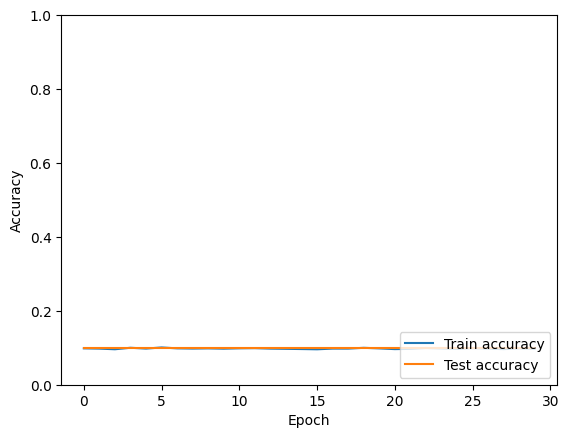

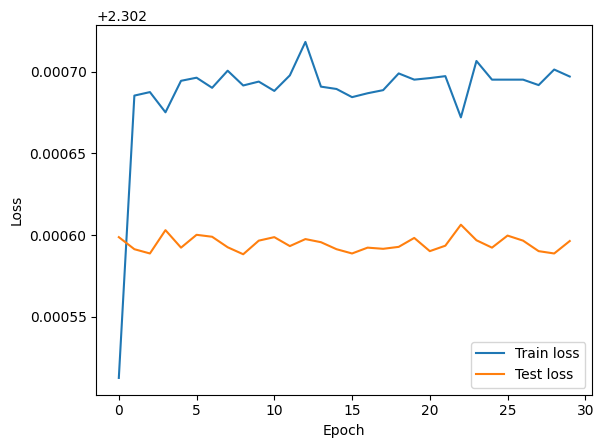

In [6]:
model = keras.Sequential([
    # YOUR IMPLEMENTATION HERE (START)

    layers.InputLayer(input_shape=(32, 32, 3)),

    # Block 1: 64 filters, 32x32 spatial
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),
    layers.Dropout(0.2),  # Dropout after first block

    # Block 2: 128 filters, 16x16 spatial
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),
    layers.Dropout(0.2),  # Dropout after second block

    # Block 3: 256 filters, 8x8 spatial
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),
    layers.Dropout(0.3),  # Dropout after third block

    # Classification
    layers.Conv2D(10, kernel_size=(1, 1), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),

    # Dropout before final Dense layer
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')

    # YOUR IMPLEMENTATION HERE (END)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=30, batch_size=128)
plot_history(history)

# 6. Data Augmentation

Data augmentation (DA) is a common and realtively cheap way to increase model performance.

In Keras, DA transformations can be added to the model definition simply as additional layers. They will only run while training the model (`fit` and friends), but not during evaluation or other scenarios.

Try adding [random rotatiosn](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomRotation), [flips](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomFlip) and other [random DA layers](https://keras.io/api/layers/preprocessing_layers/image_augmentation/) between the input layer and the first convolutional layer. Then you can simply train your model as usual.

Note that you'll probably need to train the model a bit more than in the previous cases.

Note: This way of applying DA is relatively new in Keras and differs significantly from the previous API (replaced in ~2020) that used the `ImageDataGenerator` class, so beware when browsing documentation and tutorials.


Answer:

* Try using extreme DA transformations, such as cropping more than 50% of the image. What effect does that have on the model and the train/test performance?
* By default, data augmentation is only applied to the training set, but the test set is not augmented. Why do you think that is? In which cases would it make sense to apply DA also to the test set?.
* Given your previous answers, think of 3 transformations that would not help the model perform better on the test set.




Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.0975 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.0974 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.0958 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.0974 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.0993 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.0980 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.0972 - loss: 2.3027 - 

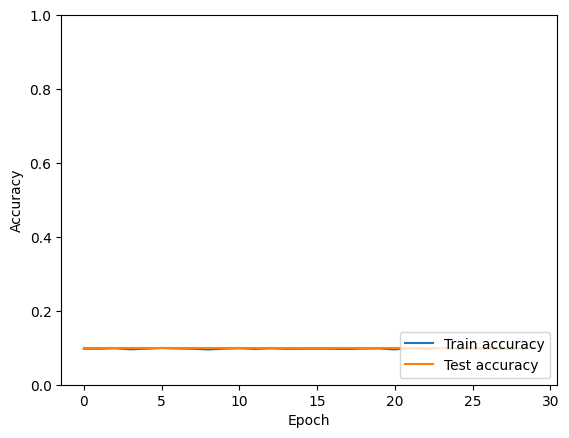

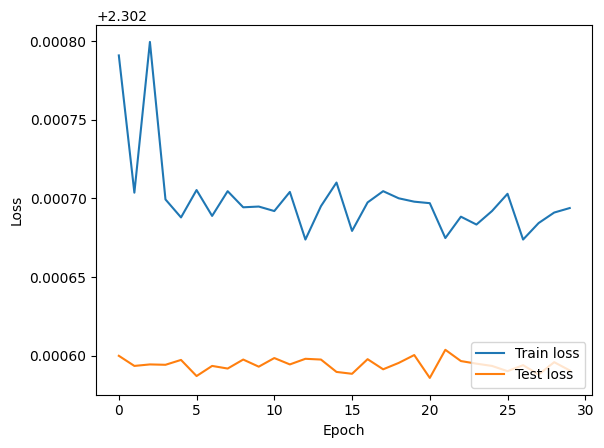

In [7]:
from keras.layers import RandomRotation, RandomFlip, RandomZoom, RandomTranslation

model = keras.Sequential([
    # YOUR IMPLEMENTATION HERE (START)

    layers.InputLayer(input_shape=(32, 32, 3)),

    # Data Augmentation layers (only active during training)
    RandomRotation(0.2),  # Random rotation ±20%
    RandomFlip("horizontal"),  # Random horizontal flip
    RandomZoom(0.2),  # Random zoom
    RandomTranslation(0.2, 0.2),  # Random translation

    # Block 1: 64 filters, 32x32 spatial
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),
    layers.Dropout(0.2),

    # Block 2: 128 filters, 16x16 spatial
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),
    layers.Dropout(0.2),

    # Block 3: 256 filters, 8x8 spatial
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same', strides=(2, 2)),
    layers.Dropout(0.3),

    # Classification
    layers.Conv2D(10, kernel_size=(1, 1), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')

    # YOUR IMPLEMENTATION HERE (END)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=30, batch_size=128)
plot_history(history)